# Genetic Algorithm for N-Queens

A genetic algorithm evolves a population of candidate boards using selection, crossover, and mutation. The file name refers to eight queens, but the supplied experiment uses **30 queens**.

Run the cells in order. Only Matplotlib needs installation; <code>random</code> is part of Python. The default population and generation limits can be computationally expensive; a smaller board is useful for quick experiments.


## Parameters and Reproducibility

The population contains 1,000 candidates and search allows up to 1,000 generations. The mutation rate is the probability of swapping two positions in one child, not a probability per queen. The seed fixes the random sequence.

For $n$ queens, the target fitness is $n(n-1)/2$, the number of unordered pairs. With 30 queens, it is 435. If you change the board size, rerun the definition cells too: Python evaluates default parameter values when a function is defined.


In [ ]:
import random
import matplotlib.pyplot as plt

# Parameters
default_board_size = 30
population_size = 1000
generations = 1000
mutation_rate = 0.3

# print target fitness
print("Target Fitness:", (default_board_size * (default_board_size - 1)) // 2)

random.seed(0)
# random.seed(1)
# random.seed(2)



## Score a Board

Entry <code>board[i]</code> is the row occupied by the queen in column <code>i</code>. The fitness function checks each pair once. Different rows and a row difference unequal to the column difference mean that the pair does not attack.

Higher fitness is better. Reaching the target means every pair is non-attacking. Evaluation takes quadratic time in the number of queens.


In [ ]:
# Fitness function: Counts non-attacking pairs
def fitness(board):
    non_attacking = 0
    n = len(board)
    for i in range(n):
        for j in range(i + 1, n):
            if board[i] != board[j] and abs(board[i] - board[j]) != j - i:
                non_attacking += 1
    return non_attacking



## Create One Candidate

A random permutation places exactly one queen in each column and each row. This representation rules out row and column conflicts by construction; diagonal conflicts remain for the search to resolve.


In [ ]:
# Generate an individual (random permutation of row positions)
def generate_individual(n=default_board_size):
    return random.sample(range(n), n)



## Create the Population

Each individual is sampled independently. The population is a list of candidate permutations, not one shared board referenced many times.


In [ ]:
# Create initial population
def generate_population(size, n=default_board_size):
    return [generate_individual(n) for _ in range(size)]



## Select a Parent

Tournament selection samples ten candidates and returns the fittest. Stronger candidates are favored without making every parent the global best. The population must contain at least ten individuals.


In [ ]:
# Selection: Tournament selection
def selection(population):
    return max(random.sample(population, 10), key=fitness)



## Combine Two Parents

The crossover copies a slice from the first parent, then fills the empty positions with unused values in the second parent's order. This preserves the permutation constraint: no row is duplicated or lost. It does not guarantee fewer diagonal conflicts.


In [ ]:
# Crossover: Order Crossover (OX)
def crossover(parent1, parent2):
    n = len(parent1)
    start, end = sorted(random.sample(range(n), 2))
    child = [-1] * n
    child[start:end] = parent1[start:end]
    fill_values = [x for x in parent2 if x not in child]
    child = [fill_values.pop(0) if x == -1 else x for x in child]
    return child



## Mutate a Child

A mutation swaps two entries in place. Swapping preserves the one-queen-per-row constraint while changing diagonal relationships. The function receives a newly created child, so it does not directly mutate its parents.


In [ ]:
# Mutation: Swap mutation
def mutate(individual):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]
    return individual



## Evolve the Population

Each generation ranks candidates, prints average fitness, and checks whether the best is a solution. **Elitism** copies the best individual into the next generation; selection, crossover, and mutation fill the remaining slots.

Keeping an elite protects the best score, but does not require average fitness to increase. If no solution is found at the checked generations, the function returns <code>None</code>. This is stochastic optimization, not a proof that an instance has no solution.


In [ ]:
# Genetic Algorithm main loop
def genetic_algorithm():
    population = generate_population(population_size)
    for generation in range(generations):
        population = sorted(population, key=fitness, reverse=True)
        # print the average fitness of the population
        print("Generation:", generation, "Average Fitness:", sum(fitness(x) for x in population) / len(population))
        if fitness(population[0]) == (default_board_size * (default_board_size - 1)) // 2:
            return population[0]
        next_gen = [population[0]]  # Elitism: Carry best individual forward
        while len(next_gen) < population_size:
            p1, p2 = selection(population), selection(population)
            child = mutate(crossover(p1, p2))
            next_gen.append(child)
        population = next_gen
    return None



## Run and Inspect Fitness

The saved output includes the setup's target-fitness line followed by generation statistics and a solution. Check that the final fitness equals the target and that the returned list is a permutation.

The final print assumes a solution was found. For new parameter choices, check for <code>None</code> before calling <code>fitness</code> or drawing the result.


In [ ]:
# Run the algorithm
solution = genetic_algorithm()
print("Solution:", solution)
print("Fitness:", fitness(solution))

Target Fitness: 435
Generation: 0 Average Fitness: 415.537
Generation: 1 Average Fitness: 417.595
Generation: 2 Average Fitness: 418.247
Generation: 3 Average Fitness: 418.498
Generation: 4 Average Fitness: 418.936
Generation: 5 Average Fitness: 419.174
Generation: 6 Average Fitness: 419.268
Generation: 7 Average Fitness: 419.284
Generation: 8 Average Fitness: 419.781
Generation: 9 Average Fitness: 420.118
Generation: 10 Average Fitness: 420.336
Generation: 11 Average Fitness: 420.55
Generation: 12 Average Fitness: 421.053
Generation: 13 Average Fitness: 421.503
Generation: 14 Average Fitness: 422.189
Generation: 15 Average Fitness: 422.798
Generation: 16 Average Fitness: 423.42
Generation: 17 Average Fitness: 424.657
Generation: 18 Average Fitness: 426.6
Generation: 19 Average Fitness: 429.307
Generation: 20 Average Fitness: 431.576
Generation: 21 Average Fitness: 432.148
Generation: 22 Average Fitness: 432.169
Generation: 23 Average Fitness: 432.173
Generation: 24 Average Fitness: 43

## Draw a Candidate

The plotting helper places a queen at each <code>(column, board[column])</code> coordinate. The inverted vertical axis makes row 0 the top row. Drawing is a visual check; the pairwise fitness calculation is the actual conflict test.


In [ ]:
# draw the solution on a chessboard
def draw_board(board):
    n = len(board)
    plt.figure(figsize=(6, 6))
    plt.xlim(0, n)
    plt.ylim(0, n)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xticks([])
    plt.yticks([])
    plt.gca().invert_yaxis()
    for i in range(n):
        for j in range(n):
            plt.gca().add_patch(plt.Rectangle((i, j), 1, 1, fc='white' if (i + j) % 2 == 0 else 'gray'))
            if j == board[i]:
                plt.text(i + 0.5, j + 0.5, '♕', ha='center', va='center', fontsize=12, color='red')
    plt.show()



## Inspect the Board

No two queens should share a row, column, or diagonal. On a large board, inspect the numeric fitness as well as the picture.


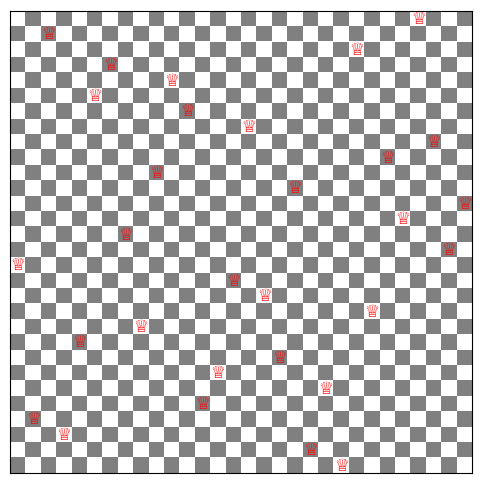

In [ ]:
draw_board(solution)

## Explore the Design Choices

- Compare several seeds rather than judging a setting by a single successful run.
- Lower mutation toward zero. Does the population lose useful diversity?
- Compare the best fitness with the printed average. Why can they move differently?

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Compare a distribution of outcomes.** Different seeds change the initial population, tournament samples, crossover choices, and mutations. Across seeds, compare the fraction of runs that reach fitness 435 and the generations needed by successful runs. Keep population size, mutation rate, and generation budget fixed. Report unsuccessful runs too; one quick success is not representative.
2. **Very low mutation can reduce diversity.** Selection repeatedly favors similar strong candidates. If parents become identical, crossover alone cannot create a different permutation; swap mutation can introduce new arrangements. Zero mutation does not guarantee failure, since initial diversity and crossover may suffice. Excessively high mutation can also disrupt useful arrangements, so the best rate is an empirical question.
3. **Elitism protects the maximum, not the mean.** The best individual survives unchanged, so the population's best fitness cannot decrease between generations. The other individuals are replaced by children that may be worse than their parents, allowing average fitness to fall even while the best score holds steady or improves.

</details>

**Takeaway:** representation enforces some constraints automatically; fitness and genetic operators handle the constraints that remain.
